# 🎯 Holiday Package Prediction — Problem Statement

## 1️⃣ Problem Statement  

**Trips & Travel.Com** aims to establish a viable business model to expand its customer base by introducing a new product offering — the **Wellness Tourism Package**.

Currently, the company offers five types of travel packages:
- Basic  
- Standard  
- Deluxe  
- Super Deluxe  
- King  

Analysis of last year’s customer data shows that **only 18% of contacted customers purchased a package**. The marketing cost was significantly high because customers were contacted **at random**, without leveraging available customer information.

### 🧘 New Business Goal  
The company is now planning to launch a **Wellness Tourism Package**, which is defined as:

> *Travel that allows the traveler to maintain, enhance, or kick-start a healthy lifestyle, and support or increase one’s sense of well-being.*

To improve efficiency, the company wants to **use historical and customer data** to:
- Identify customers who are more likely to purchase the new package  
- Reduce unnecessary marketing efforts  
- Increase conversion rates  
- Optimize marketing expenditure  

This problem is formulated as a **Binary Classification Task**, where the model predicts whether a customer is likely to purchase the holiday package or not.

---

## 2️⃣ Data Collection  

The dataset is collected from Kaggle:  
🔗 https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction  

### 📊 Dataset Description  
- **Number of Rows:** 4,888  
- **Number of Columns:** 20  
- **Target Variable:** `ProdTaken`  
  - `1` → Customer purchased the package  
  - `0` → Customer did not purchase the package  

The dataset contains:
- **Customer Demographics** (Age, Gender, Marital Status, etc.)  
- **Travel Preferences** (Number of trips, Passport status, etc.)  
- **Sales Interaction Data** (Pitch duration, Type of contact, Follow-ups, etc.)  

These features will be used to train a **Random Forest Classification model** to predict high-potential customers for the Wellness Tourism Package.

---


In [108]:
# ================================
# Importing Required Libraries
# ================================

# Data manipulation and analysis
import pandas as pd                  # For handling structured data (DataFrames, CSV, Excel, etc.)
import numpy as np                   # For numerical operations and array-based computations

# Data visualization
import matplotlib.pyplot as plt      # For static plots and charts
import seaborn as sns                # For statistical and advanced visualizations
import plotly.express as px          # For interactive and dynamic visualizations

# Warning control
import warnings                      # To manage and suppress unnecessary warnings during execution

# Suppress all warning messages for cleaner notebook output
warnings.filterwarnings("ignore")

In [109]:
# ================================
# Load the Dataset
# ================================

# Read the holiday package dataset into a pandas DataFrame
travel_df = pd.read_csv('Travel.csv')

# Display the first 5 rows to understand the data structure and feature values
display(travel_df.head())

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# 🧹 Data Cleaning & Understanding the Dataset  

## 📌 Overview  
Before building any machine learning model, it is essential to clean and understand the dataset. This step ensures data quality, consistency, and reliability, which directly impacts model performance.

In this section, we will perform the following tasks:

---

## 1️⃣ Handling Missing Values  
Missing values can introduce bias and reduce the effectiveness of the model. We will:
- Identify columns with missing values  
- Analyze the percentage of missing data per feature  
- Apply appropriate strategies such as:
  - **Mean/Median Imputation** for numerical features  
  - **Mode Imputation** for categorical features  
  - Dropping rows or columns where missing values exceed a reasonable threshold  

---

## 2️⃣ Handling Duplicate Records  
Duplicate records can distort patterns in the dataset and lead to biased learning. We will:
- Check for duplicate rows  
- Remove duplicates if found  
- Verify dataset size before and after cleaning  

---

## 3️⃣ Data Type Validation  
Correct data types are critical for accurate analysis and modeling. We will:
- Inspect data types of all features  
- Convert columns to appropriate types (e.g., `int`, `float`, `category`)  
- Ensure categorical and numerical features are properly classified  

---

## 4️⃣ Understanding the Dataset Structure  
To gain a deeper understanding of the data, we will:
- Review dataset shape (rows and columns)  
- Generate statistical summaries for numerical features  
- Explore unique values in categorical features  
- Identify potential anomalies and inconsistencies  

---

## 🎯 Outcome  
By the end of this section, the dataset will be:
- Free from critical missing and duplicate values  
- Properly typed and structured  
- Well-understood in terms of feature distributions and data quality  

This prepares the data for **Exploratory Data Analysis (EDA)** and **Feature Engineering**.


In [110]:
# ================================
# Check for Missing Values
# ================================

# Calculate the total number of missing (null) values in each column
missing_values = travel_df.isnull().sum()

# Display the missing values count for better readability
missing_values


CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [111]:
# ================================
# Analyze Gender Distribution
# ================================

# Count the number of occurrences of each unique value in the 'Gender' column
gender_distribution = travel_df['Gender'].value_counts()

# Display the distribution
gender_distribution


Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [112]:
# ====================================
# Analyze Type of Contact Distribution
# ====================================

# Count the number of occurrences of each unique value in the 'TypeofContact' column
contact_type_distribution = travel_df['TypeofContact'].value_counts()

# Display the distribution
contact_type_distribution


TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [113]:
# ===================================
# Analyze Marital Status Distribution
# ===================================

# Count the number of occurrences of each unique value in the 'MaritalStatus' column
marital_status_distribution = travel_df['MaritalStatus'].value_counts()

# Display the distribution
marital_status_distribution


MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [114]:
# ================================
# Standardize Categorical Values
# ================================

# Fix inconsistent values in the 'Gender' column
# Replace 'Fe Male' with the standardized label 'Female'
travel_df['Gender'] = travel_df['Gender'].replace('Fe Male', 'Female')

# Standardize marital status values for consistency
# Replace 'Single' with 'Unmarried'
travel_df['MaritalStatus'] = travel_df['MaritalStatus'].replace('Single', 'Unmarried')


In [115]:
display(travel_df.head())

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [116]:
# =====================================
# Identify Features with Missing Values
# =====================================

# Store column names that have one or more missing (NaN) values
features_with_nan = travel_df.columns[travel_df.isnull().any()]

# Display the list of features containing missing values
features_with_nan


Index(['Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting',
       'MonthlyIncome'],
      dtype='object')

In [117]:
# =====================================
# Missing Values Percentage per Feature
# =====================================

# Calculate the percentage of missing values in each column
missing_percentage = (travel_df.isnull().sum() / len(travel_df)) * 100

# Convert to a DataFrame for better readability
missing_percentage_df = missing_percentage.reset_index()
missing_percentage_df.columns = ['Feature', 'Missing Percentage (%)']

# Display only features that actually have missing values
missing_percentage_df = missing_percentage_df[missing_percentage_df['Missing Percentage (%)'] > 0]

# Sort by highest missing percentage
missing_percentage_df = missing_percentage_df.sort_values(by='Missing Percentage (%)', ascending=False)

# Display the result
missing_percentage_df


,Feature,Missing Percentage (%)
5,DurationOfPitch,5.135025
19,MonthlyIncome,4.766776
2,Age,4.623568
13,NumberOfTrips,2.864157
17,NumberOfChildrenVisiting,1.350245
9,NumberOfFollowups,0.920622
11,PreferredPropertyStar,0.531915
3,TypeofContact,0.511457


In [118]:
# ================================
# Statistical Summary of Numerical Features with Missing Values
# ================================

# Select only the columns that contain missing values
# From those, filter only numerical columns (exclude categorical/object types)
numerical_missing_summary = travel_df[features_with_nan].select_dtypes(exclude='object').describe()

# Display the statistical summary
numerical_missing_summary


,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


# 🛠️ Imputing Missing Values  

## 📌 Overview  
Missing values can negatively impact model performance and lead to biased predictions. In this step, we apply **feature-specific imputation strategies** based on the nature and distribution of each variable.

We use:
- **Median Imputation** for continuous numerical features (robust to outliers)  
- **Mode Imputation** for categorical or discrete features (preserves most frequent class)  

---

## 🧪 Imputation Strategy  

| Feature Name               | Data Type              | Imputation Method | Rationale |
|---------------------------|------------------------|-------------------|-----------|
| `Age`                    | Continuous Numerical  | Median           | Robust to outliers and skewed distribution |
| `TypeofContact`         | Categorical           | Mode             | Preserves most frequent contact type |
| `DurationOfPitch`      | Continuous Numerical  | Median           | Minimizes impact of extreme values |
| `NumberOfFollowups`    | Discrete Numerical   | Mode             | Maintains most common follow-up behavior |
| `PreferredPropertyStar`| Discrete Numerical   | Mode             | Preserves dominant property preference |
| `NumberOfTrips`        | Continuous Numerical | Median           | Reduces effect of extreme trip counts |
| `NumberOfChildrenVisiting` | Discrete Numerical | Mode         | Keeps most common family structure |
| `MonthlyIncome`        | Continuous Numerical | Median           | Robust against income outliers |

---

## 🎯 Expected Outcome  
After imputation:
- The dataset will contain **no missing values** in critical features  
- Data distributions will remain stable and realistic  
- The dataset will be ready for **Encoding, Feature Engineering, and Model Training**  

This structured approach ensures data quality while maintaining the business and statistical integrity of each feature.


In [119]:
# ================================
# Impute Missing Values
# ================================

# 1. Impute Median for Continuous Numerical Features
travel_df['Age'].fillna(travel_df['Age'].median(), inplace=True)
travel_df['DurationOfPitch'].fillna(travel_df['DurationOfPitch'].median(), inplace=True)
travel_df['NumberOfTrips'].fillna(travel_df['NumberOfTrips'].median(), inplace=True)
travel_df['MonthlyIncome'].fillna(travel_df['MonthlyIncome'].median(), inplace=True)

# 2. Impute Mode for Categorical / Discrete Features
travel_df['TypeofContact'].fillna(travel_df['TypeofContact'].mode()[0], inplace=True)
travel_df['NumberOfFollowups'].fillna(travel_df['NumberOfFollowups'].mode()[0], inplace=True)
travel_df['PreferredPropertyStar'].fillna(travel_df['PreferredPropertyStar'].mode()[0], inplace=True)
travel_df['NumberOfChildrenVisiting'].fillna(travel_df['NumberOfChildrenVisiting'].mode()[0], inplace=True)

# ================================
# Validation Check
# ================================

# Confirm that no missing values remain in the dataset
travel_df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [120]:
# ===================================
# Drop Irrelevant / Identifier Column
# ===================================

# 'CustomerID' is a unique identifier and does not contribute to model learning
# Removing it to prevent the model from learning meaningless patterns
travel_df.drop('CustomerID', inplace=True, axis=1)


In [121]:
# ================================
# Feature Engineering: Total Visitors
# ================================

# Create a new feature that represents the total number of people visiting
# This combines adults and children into a single, meaningful business feature

travel_df['TotalVisiting'] = (
    travel_df['NumberOfPersonVisiting'] +
    travel_df['NumberOfChildrenVisiting']
)

# Drop the original columns as they are now represented by 'TotalVisiting'
travel_df.drop(
    columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'],
    inplace=True
)

In [122]:
# ================================
# Identify Numerical Features
# ================================

# Select all numerical columns (int and float types)
numerical_features = travel_df.select_dtypes(include=['int64', 'float64']).columns

# Print the total number of numerical features
print(f"Number of Numerical Features: {len(numerical_features)}")

# Display the list of numerical feature names
numerical_features

Number of Numerical Features: 12


Index(['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object')

In [123]:
# ================================
# Identify Categorical Features
# ================================

# Select all categorical columns (object / category data types)
categorical_features = travel_df.select_dtypes(include=['object', 'category']).columns

# Print the total number of categorical features
print(f"Number of Categorical Features: {len(categorical_features)}")

# Display the list of categorical feature names
categorical_features


Number of Categorical Features: 6


Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [124]:
# ================================
# Identify Discrete Numerical Features
# ================================

# Discrete features are numerical columns with a limited number of unique values
# (e.g., counts, ratings, or categorical numbers)
discrete_features = [
    feature for feature in numerical_features
    if travel_df[feature].nunique() < 20
]

# Print the total number of discrete numerical features
print(f"Number of Discrete Numerical Features: {len(discrete_features)}")

# Display the list of discrete feature names
discrete_features

Number of Discrete Numerical Features: 9


['ProdTaken',
 'CityTier',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'TotalVisiting']

In [125]:
# ================================
# Identify Continuous Numerical Features
# ================================

# Continuous features are numerical columns with a high number of unique values
# Typically representing measurements or real-valued quantities
continuous_features = [
    feature for feature in numerical_features
    if feature not in discrete_features
]

# Print the total number of continuous numerical features
print(f"Number of Continuous Numerical Features: {len(continuous_features)}")

# Display the list of continuous feature names
continuous_features

Number of Continuous Numerical Features: 3


['Age', 'DurationOfPitch', 'MonthlyIncome']

# 🧠 Train-Test Split & Model Training  

## 📌 Overview  
In this phase, the cleaned and preprocessed dataset is prepared for machine learning by splitting it into **training** and **testing** sets. The training set is used to teach the model underlying patterns in the data, while the testing set is used to evaluate how well the model generalizes to unseen data.

---

## 1️⃣ Feature and Target Separation  
We first separate the dataset into:
- **X (Features):** All independent variables used for prediction  
- **y (Target):** The dependent variable `ProdTaken`, which indicates whether a customer purchased the holiday package  
  - `1` → Purchased  
  - `0` → Not Purchased  

---

## 2️⃣ Train-Test Split  
The dataset is split into two parts:
- **Training Set:** Used to train the Random Forest model  
- **Testing Set:** Used to evaluate model performance  

A standard split ratio of **80% training** and **20% testing** is used to:
- Ensure sufficient data for learning  
- Retain enough unseen data for reliable performance evaluation  

We also apply a **random state** to ensure reproducibility of results.

---

## 3️⃣ Model Training — Random Forest Classifier  
We use the **Random Forest Classification algorithm**, an ensemble learning method that:
- Builds multiple decision trees using random subsets of data and features  
- Aggregates predictions using majority voting  
- Reduces overfitting and improves model stability and accuracy  

Key benefits of Random Forest:
- Handles both numerical and categorical features effectively  
- Resistant to outliers and noise  
- Provides feature importance for model interpretability  

---

## 📈 Expected Outcome  
At the end of this stage, we will have:
- A **trained Random Forest model**  
- Predictions on the test dataset  
- A foundation for evaluating performance using classification metrics and visualizations  

This step bridges data preparation and **model evaluation & optimization**.


In [126]:
# ================================
# Feature-Target Separation
# ================================

from sklearn.model_selection import train_test_split

# Separate independent features (X) and target variable (y)
X = travel_df.drop('ProdTaken', axis=1)  # All predictor variables
y = travel_df['ProdTaken']              # Target variable (0 = Not Purchased, 1 = Purchased)

In [127]:
# ================================
# Train-Test Split
# ================================

# Split the data into training and testing sets
# 80% for training and 20% for testing
# Stratify ensures the class distribution of the target variable is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Display the shape of the split datasets
X_train.shape, X_test.shape


((3910, 17), (978, 17))

## 📊 Why `stratify = y` is Important in Train-Test Split  

## 📌 Problem Context  
In this dataset, the target variable `ProdTaken` is **imbalanced**, where only a small percentage of customers (approximately 18%) purchase the holiday package, while the majority do not.

This class imbalance can cause issues during model training and evaluation if the data is split randomly without preserving the original class distribution.

---

## ⚠️ What Happens Without Stratification?  
If `stratify = y` is not used:
- The training set may contain **too many or too few positive cases (buyers)**  
- The test set may not reflect real-world data distribution  
- Model performance metrics such as **accuracy, precision, and recall** can become misleading  
- The model may fail to properly learn patterns related to the minority class  

---

## ✅ What Stratification Does  
Using `stratify = y` ensures that:
- Both **training and testing sets maintain the same class proportion** as the original dataset  
- The minority class (`ProdTaken = 1`) is properly represented in both splits  
- Model evaluation becomes **fair, stable, and reliable**  

---

## 🎯 Business Impact  
Since the goal is to identify **customers likely to purchase a holiday package**, preserving buyer representation in both datasets helps the model:
- Learn meaningful patterns for high-value customers  
- Avoid bias toward predicting only non-buyers  
- Deliver more trustworthy predictions for marketing and targeting decisions  

---

## 🧠 Summary  
> `stratify = y` is essential when working with **imbalanced classification problems** because it preserves the target class distribution across training and testing datasets, leading to more reliable model training and evaluation.


In [128]:
# ================================
# Separate Categorical and Numerical Features
# ================================

# Define data types that represent categorical features
categories = ['object', 'category']

# Select categorical features based on data types
categorical_features = X.select_dtypes(include=categories).columns

# Select numerical features by excluding categorical data types
numerical_features = X.select_dtypes(exclude=categories).columns

# Display feature counts
print(f"Number of Categorical Features: {len(categorical_features)}")
print(f"Number of Numerical Features: {len(numerical_features)}")

# Display feature names
categorical_features, numerical_features


Number of Categorical Features: 6
Number of Numerical Features: 11


(Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation'],
       dtype='object'),
 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
        'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
        'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
       dtype='object'))

In [129]:
# ================================
# Feature Preprocessing Pipeline
# ================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Transformer for numerical features
# StandardScaler scales numerical values to have:
# - Mean = 0
# - Standard Deviation = 1
# Example:
# If MonthlyIncome values are [20000, 50000, 100000],
# after scaling they become something like [-0.8, 0.1, 1.2].
# This prevents large-range features from dominating smaller ones.
numerical_transformer = StandardScaler()

# Transformer for categorical features
# OneHotEncoder converts each category into a separate binary column (0 or 1).
#
# Example:
# Feature: Gender = ['Male', 'Female']
# Without drop:
#   Gender_Male, Gender_Female
#   Male   -> [1, 0]
#   Female -> [0, 1]
#
# With drop='first':
#   Gender_Female
#   Male   -> [0]
#   Female -> [1]
#
# The dropped category (Gender_Male) can be inferred from Gender_Female = 0,
# which avoids redundant information and reduces feature dimensionality.
#
# handle_unknown='ignore':
# This ensures the model does NOT crash when it encounters a new category
# during prediction that was not seen during training.
#
# Example:
# If training data has TypeofContact = ['Self Enquiry', 'Company Invited']
# and during prediction a new value appears: 'Walk-in'
# Without handle_unknown='ignore' -> ERROR (model cannot encode this value)
# With handle_unknown='ignore'    -> Encodes all zeros for that feature group
#                                  and allows prediction to continue safely.
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

# Combine preprocessing steps for numerical and categorical features
# ColumnTransformer applies:
# - OneHotEncoding to categorical features
# - Scaling to numerical features
# in a single, clean preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", one_hot_encoder, categorical_features),
        ("StandardScaler", numerical_transformer, numerical_features)
    ]
)


In [130]:
# ================================
# Apply Preprocessing to Train and Test Sets
# ================================

# Fit the preprocessor ONLY on the training data and transform it
# Why?
# The training set is used to "learn" preprocessing parameters such as:
# - Mean and standard deviation for StandardScaler
# - Category mappings for OneHotEncoder
#
# Example:
# If MonthlyIncome in training data has:
#   Mean = 50,000 and Std = 20,000
# These values are learned here and stored inside the preprocessor.
#
# We MUST NOT use the test data to learn these values,
# because that would cause "Data Leakage" — the model would indirectly
# see information from the test set during training.
#X_train = preprocessor.fit_transform(X_train)

# Transform the test data using the SAME parameters learned from training data
# This ensures:
# - Both datasets are on the same scale
# - Categories are encoded consistently
#
# Example:
# If 'Female' was encoded as [1] during training,
# it will be encoded the same way in the test set.
#
# We DO NOT call fit_transform() here because we do NOT want to
# recalculate means, standard deviations, or category mappings.
#X_test = preprocessor.transform(X_test)


# 🌲 Random Forest Classifier — Model Training  

## 📌 Overview  
In this stage, we train a **Random Forest Classifier** to predict whether a customer is likely to purchase the holiday package. Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions using majority voting to produce a robust and high-performing classification model.

---

## 🧠 Why Random Forest?  
Random Forest is well-suited for this problem because it:
- Handles **non-linear relationships** and complex feature interactions  
- Works well with both **numerical and encoded categorical features**  
- Is **robust to outliers and noise** in the data  
- Reduces overfitting by averaging predictions from multiple trees  
- Provides **feature importance scores** for model interpretability  

---

## ⚙️ Training Strategy  
We train the model using the **preprocessed training dataset**, which includes:
- One-hot encoded categorical features  
- Scaled numerical features  

The model learns decision boundaries by:
- Randomly sampling subsets of data (bootstrap sampling)  
- Selecting random subsets of features at each split  
- Building multiple independent decision trees  

---

## 📈 Model Configuration  
Key hyperparameters used in training:
- `n_estimators` → Number of trees in the forest  
- `max_depth` → Maximum depth of each tree (controls model complexity)  
- `min_samples_split` → Minimum number of samples required to split a node  
- `random_state` → Ensures reproducibility of results  

These parameters can be further optimized using **Grid Search or Random Search** to improve performance.

---

## 🎯 Expected Outcome  
After training, the model will:
- Generate predictions on unseen test data  
- Be evaluated using classification metrics such as **Accuracy, Precision, Recall, F1-score**, and **Confusion Matrix**  
- Provide insights into which features most influence customer purchase decisions  

This step forms the foundation for **model evaluation, tuning, and business interpretation**.


In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score
    
)

| Metric                   | Purpose                                     | Why It Matters for This Problem                                |
| ------------------------ | ------------------------------------------- | -------------------------------------------------------------- |
| `accuracy_score`         | Overall correctness                         | Quick sanity check, but can be misleading with class imbalance |
| `precision_score`        | How many predicted buyers are actual buyers | Important for **marketing cost efficiency**                    |
| `recall_score`           | How many actual buyers you correctly find   | Important for **not missing high-value customers**             |
| `f1_score`               | Balance of precision & recall               | Best single metric for **imbalanced data**                     |
| `roc_auc_score`          | Overall model separability                  | Measures how well model distinguishes buyers vs non-buyers     |
| `roc_curve`              | Threshold analysis                          | Helps choose optimal decision threshold                        |
| `ConfusionMatrixDisplay` | Visual performance                          | Business-friendly performance explanation                      |
| `classification_report`  | All metrics in one                          | Interview-ready summary                                        |


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- Balanced Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
- ROC-AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9407
- Balanced Accuracy: 0.8487
- Precision: 0.9773
- Recall: 0.7011
- F1 Score: 0.8165
- ROC-AUC: 0.9605

Classification Report (Test Set)
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       794
           1       0.98      0.70      0.82       184

    accuracy                           0.94       978
   macro avg       0.96      0.85      0.89       978
weighted avg       0.94      0.94      0.94       978



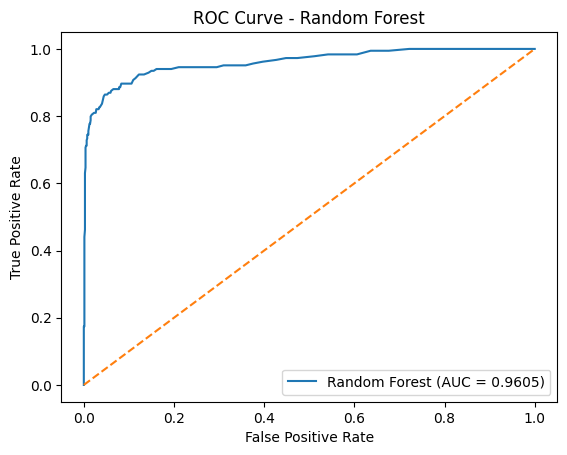

In [132]:
from sklearn.pipeline import Pipeline

models = {
    # Random Forest (Ensemble of Decision Trees)
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        # n_estimators:
        # Number of decision trees in the forest.
        # More trees generally improve performance and stability,
        # but increase training time. 200 is a good balance.

        random_state=42
        # random_state:
        # Ensures reproducibility of bootstrap sampling
        # and feature selection across runs.
    )
}

# ================================
# Model Evaluation Metrics
# ================================
# This loop trains multiple machine learning models using a unified
# preprocessing + modeling pipeline and evaluates them using
# business-relevant and statistically sound classification metrics.

for model_name, model in models.items():

    # ================================
    # Build Pipeline
    # ================================
    # The Pipeline ensures that:
    # 1. Preprocessing is ALWAYS applied before model training and prediction
    # 2. The preprocessor is fit ONLY on training data (prevents data leakage)
    # 3. The same transformations are consistently applied during testing
    #    and future real-world predictions (deployment-ready design)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),  # Applies encoding + scaling
        ("model", model)                # Trains the selected ML algorithm
    ])

    # ================================
    # Model Training
    # ================================
    # Internally, this performs:
    # 1. preprocessor.fit_transform(X_train)
    #    - Learns scaling parameters (mean, std)
    #    - Learns category mappings for OneHotEncoder
    # 2. model.fit(transformed_X_train, y_train)
    #
    # This ensures that NO information from the test set
    # influences the preprocessing or training process.
    pipeline.fit(X_train, y_train)

    # ================================
    # Predictions (Class Labels)
    # ================================
    # These are the final predicted classes:
    # 0 -> Customer did NOT purchase the package
    # 1 -> Customer DID purchase the package
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # ================================
    # Predictions (Probabilities)
    # ================================
    # These represent the model's confidence that a customer belongs
    # to the positive class (ProdTaken = 1).
    #
    # Example:
    # A value of 0.82 means the model estimates an 82% chance
    # that the customer will purchase the package.
    #
    # These probabilities are REQUIRED for ROC-AUC calculation,
    # which measures how well the model separates buyers vs non-buyers
    # across all possible classification thresholds.
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]

    # ================================
    # Training Set Metrics
    # ================================
    # These metrics help detect overfitting:
    # - Very high training performance but low test performance
    #   usually indicates the model is memorizing instead of generalizing.
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Balanced Accuracy:
    # Computes the average recall for BOTH classes (0 and 1).
    # This is critical for imbalanced datasets where one class
    # (non-buyers) dominates the other (buyers).
    #
    # Example:
    # If Recall for buyers = 0.60
    # and Recall for non-buyers = 0.95
    # Balanced Accuracy = (0.60 + 0.95) / 2 = 0.775
    train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)

    # Precision:
    # Of all customers predicted as "buyers",
    # how many actually purchased the package?
    # High precision = lower marketing waste.
    train_precision = precision_score(y_train, y_train_pred, average='binary')

    # Recall:
    # Of all actual buyers,
    # how many did the model successfully identify?
    # High recall = fewer missed high-value customers.
    train_recall = recall_score(y_train, y_train_pred, average='binary')

    # F1 Score:
    # Harmonic mean of Precision and Recall.
    # Useful single metric when balancing marketing cost (precision)
    # and revenue opportunity (recall).
    train_f1 = f1_score(y_train, y_train_pred, average='binary')

    # ROC-AUC:
    # Measures how well the model ranks buyers higher than non-buyers
    # across ALL classification thresholds.
    # A value of:
    # 0.5 -> No better than random guessing
    # 1.0 -> Perfect class separation
    train_roc_auc = roc_auc_score(y_train, y_train_proba)

    # ================================
    # Test Set Metrics (Real Performance)
    # ================================
    # These metrics represent how the model is expected to perform
    # on unseen, real-world customer data.
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Balanced Accuracy on test set:
    # Confirms whether the model maintains fair performance
    # across both buyers and non-buyers in real-world conditions.
    test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)

    test_precision = precision_score(y_test, y_test_pred, average='binary')
    test_recall = recall_score(y_test, y_test_pred, average='binary')
    test_f1 = f1_score(y_test, y_test_pred, average='binary')
    test_roc_auc = roc_auc_score(y_test, y_test_proba)

    # ================================
    # Display Results
    # ================================
    # Results are printed in a structured format
    # to allow easy comparison across different models.
    print(model_name)

    print("Model performance for Training set")
    print(f"- Accuracy: {train_accuracy:.4f}")
    print(f"- Balanced Accuracy: {train_balanced_accuracy:.4f}")
    print(f"- Precision: {train_precision:.4f}")
    print(f"- Recall: {train_recall:.4f}")
    print(f"- F1 Score: {train_f1:.4f}")
    print(f"- ROC-AUC: {train_roc_auc:.4f}")

    print("----------------------------------")

    print("Model performance for Test set")
    print(f"- Accuracy: {test_accuracy:.4f}")
    print(f"- Balanced Accuracy: {test_balanced_accuracy:.4f}")
    print(f"- Precision: {test_precision:.4f}")
    print(f"- Recall: {test_recall:.4f}")
    print(f"- F1 Score: {test_f1:.4f}")
    print(f"- ROC-AUC: {test_roc_auc:.4f}")


    # ================================
    # Classification Report
    # ================================
    # Provides precision, recall, F1-score, and support for each class
    # Class 0 -> Non-Buyers
    # Class 1 -> Buyers
    print("\nClassification Report (Test Set)")
    print(classification_report(y_test, y_test_pred))

    # ================================
    # ROC Curve Plot
    # ================================
    # The ROC curve shows the trade-off between:
    # - True Positive Rate (Recall)
    # - False Positive Rate
    #
    # It helps in choosing a better probability threshold
    # instead of always using the default 0.5 cutoff.
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {test_roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")  # Random classifier baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    print("=" * 40)
    print()



    